<a href="https://colab.research.google.com/github/cit-24-01-0024/NLP_Group_24-/blob/feature%2Fsachila-model/SENTISCOPE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q scikit-learn pandas numpy nltk textblob tensorflow matplotlib seaborn imbalanced-learn wordcloud
import pandas as pd, numpy as np, re, nltk
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!git clone -b feature/sachila-model https://github.com/cit-24-01-0024/NLP_Group_24-.git

Cloning into 'NLP_Group_24-'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 31 (delta 2), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 2.96 MiB | 4.21 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
%cd NLP_Group_24-

/content/NLP_Group_24-


In [4]:
!ls

data  README.md  requirements.txt  SENTISCOPE.ipynb


In [5]:
!pwd
!ls -l


/content/NLP_Group_24-
total 288
drwxr-xr-x 3 root root   4096 Jul 29 16:34 data
-rw-r--r-- 1 root root    125 Jul 29 16:34 README.md
-rw-r--r-- 1 root root    113 Jul 29 16:34 requirements.txt
-rw-r--r-- 1 root root 280688 Jul 29 16:34 SENTISCOPE.ipynb


In [6]:
%cd /content/NLP_Group_24-

/content/NLP_Group_24-


In [7]:
!find . -name "*.csv"

./data/raw/amazon.csv


In [8]:
import pandas as pd

df = pd.read_csv("data/raw/amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [9]:
df = pd.read_csv('data/raw/amazon.csv')
df.info()
df.head()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [10]:
def rating_to_sentiment(r):
    if r <= 2: return 'Negative'
    elif r == 3: return 'Neutral'
    else: return 'Positive'

# Convert the 'rating' column to a numeric type, coercing errors to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

df['sentiment'] = df['rating'].apply(rating_to_sentiment)
print(df['sentiment'].value_counts())

sentiment
Positive    1460
Neutral        4
Negative       1
Name: count, dtype: int64


In [11]:
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
Positive,0.996587
Neutral,0.002730
Negative,0.000683


In [12]:
from sklearn.model_selection import train_test_split
import os

# Filter out rows where the sentiment class has only one member
sentiment_counts = df['sentiment'].value_counts()
single_occurrence_sentiments = sentiment_counts[sentiment_counts == 1].index
df_filtered = df[~df['sentiment'].isin(single_occurrence_sentiments)]

# Ensure df_filtered now includes the 'final_text' column from the processed df
# (The 'final_text' column would have been added to the main df by previous cells)

train_df, test_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered['sentiment'], random_state=42)

# Create the 'data/processed' directory if it doesn't exist
os.makedirs('data/processed', exist_ok=True)

train_df.to_csv('data/processed/train.csv', index=False)
test_df.to_csv('data/processed/test.csv', index=False)

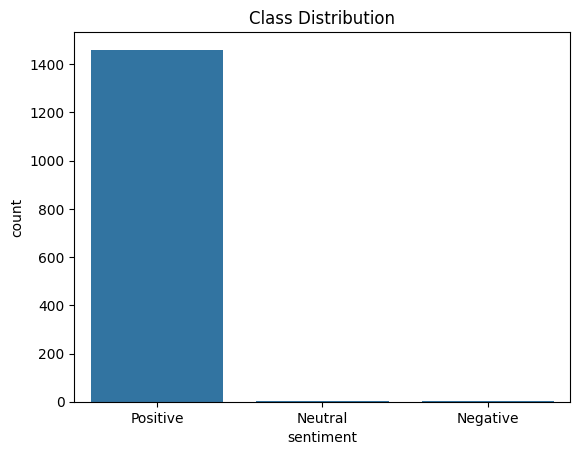

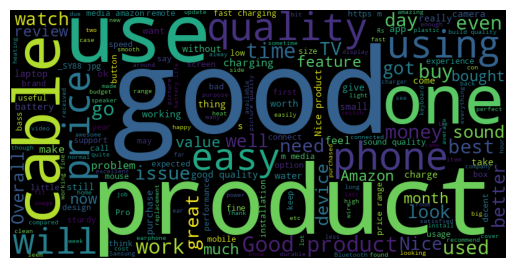

In [13]:
sns.countplot(x='sentiment', data=df)
plt.title('Class Distribution')
plt.show()

from wordcloud import WordCloud
positive_text = ' '.join(df[df.sentiment=='Positive']['review_content'].astype(str))
wc = WordCloud(width=800, height=400).generate(positive_text)
plt.imshow(wc); plt.axis('off'); plt.show()

In [14]:
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['review_content'].apply(clean_text)

In [15]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_text'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [16]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [w for w in x if w not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [17]:
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])
df['final_text'] = df['tokens'].apply(lambda x: ' '.join(x))

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [18]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split

# Re-create train_df and test_df with the 'final_text' column
# This ensures that 'final_text' is available in the split DataFrames
sentiment_counts = df['sentiment'].value_counts()
single_occurrence_sentiments = sentiment_counts[sentiment_counts == 1].index
df_filtered = df[~df['sentiment'].isin(single_occurrence_sentiments)]

train_df, test_df = train_test_split(df_filtered, test_size=0.2, stratify=df_filtered['sentiment'], random_state=42)

X_train = train_df[['final_text']]
y_train = train_df['sentiment']

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_df['final_text'])
X_test_tfidf = tfidf.transform(test_df['final_text'])

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['final_text'])
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['final_text']), maxlen=100)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['final_text']), maxlen=100)

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(train_df['sentiment'])   # Negative=0, Neutral=1, Positive=2 (alphabetical)
y_test = le.transform(test_df['sentiment'])

In [22]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
preds = lr.predict(X_test_tfidf)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=100),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_seq, y_train, epochs=10, batch_size=32,
                     validation_split=0.1, class_weight={0:2,1:3,2:1})  # adjust weights to your actual imbalance

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - accuracy: 0.9354 - loss: 1.5662 - val_accuracy: 0.9915 - val_loss: 0.0881
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.9981 - loss: 0.0695 - val_accuracy: 0.9915 - val_loss: 0.1059
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.9981 - loss: 0.0747 - val_accuracy: 0.9915 - val_loss: 0.1054
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.9981 - loss: 0.0609 - val_accuracy: 0.9915 - val_loss: 0.0855
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.9981 - loss: 0.0463 - val_accuracy: 0.9915 - val_loss: 0.0873
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9981 - loss: 0.0515 - val_accuracy: 0.9915 - val_loss: 0.0774
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9981 - loss: 0.0470 - val_accuracy: 0.9915 - val_loss: 0.0823
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.9981 - loss: 0.0480 - val_accuracy: 0

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_df['final_text'])
X_test_tfidf = tfidf.transform(test_df['final_text'])

In [25]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(train_df['sentiment'])   # Negative=0, Neutral=1, Positive=2 (alphabetical)
y_test = le.transform(test_df['sentiment'])

In [26]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
preds = lr.predict(X_test_tfidf)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(train_df['final_text'])
X_test_tfidf = tfidf.transform(test_df['final_text'])

In [28]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [29]:
preds = lr.predict(X_test_tfidf)

              precision    recall  f1-score   support

     Neutral       0.00      0.00      0.00         1
    Positive       1.00      1.00      1.00       292

    accuracy                           1.00       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99      1.00      0.99       293



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


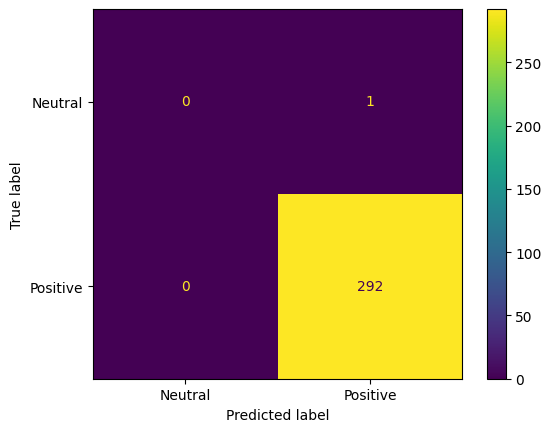

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, preds, target_names=le.classes_))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()

In [31]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['final_text'])

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['final_text']), maxlen=100)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['final_text']), maxlen=100)

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=100),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.9858 - loss: 0.4274 - val_accuracy: 0.9915 - val_loss: 0.0922
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9981 - loss: 0.0187 - val_accuracy: 0.9915 - val_loss: 0.0808
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9981 - loss: 0.0192 - val_accuracy: 0.9915 - val_loss: 0.0642
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.9981 - loss: 0.0182 - val_accuracy: 0.9915 - val_loss: 0.0673
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.9981 - loss: 0.0176 - val_accuracy: 0.9915 - val_loss: 0.0632
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.9981 - loss: 0.0173 - val_accuracy: 0.9915 - val_loss: 0.0643
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.9981 - loss: 0.0166 - val_accuracy: 0.9915 - val_loss: 0.0603
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy: 0.9981 - loss: 0.0195 - val_accuracy: 0.9915 - val

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=100),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_seq, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - accuracy: 0.9611 - loss: 0.4554 - val_accuracy: 0.9915 - val_loss: 0.0762
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.9981 - loss: 0.0237 - val_accuracy: 0.9915 - val_loss: 0.0774
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9981 - loss: 0.0170 - val_accuracy: 0.9915 - val_loss: 0.0685
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.9981 - loss: 0.0212 - val_accuracy: 0.9915 - val_loss: 0.0668
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 108ms/step - accuracy: 0.9981 - loss: 0.0188 - val_accuracy: 0.9915 - val_loss: 0.0743
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.9981 - loss: 0.0199 - val_accuracy: 0.9915 - val_loss: 0.0664
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9981 - loss: 0.0174 - val_accuracy: 0.9915 - val_loss: 0.0613
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.9981 - loss: 0.0171 - val_accuracy: 0

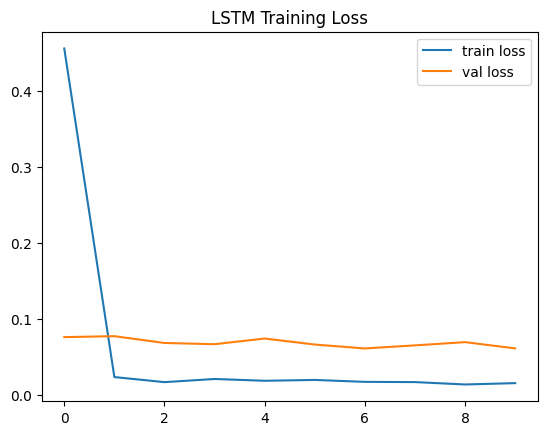

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('LSTM Training Loss')
plt.show()

In [35]:
import numpy as np

pred_probs = model.predict(X_test_seq)      # gives probabilities for each of 3 classes
preds = np.argmax(pred_probs, axis=1)       # converts to actual class label (0, 1, or 2)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step


              precision    recall  f1-score   support

     Neutral       0.00      0.00      0.00         1
    Positive       1.00      1.00      1.00       292

    accuracy                           1.00       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99      1.00      0.99       293



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


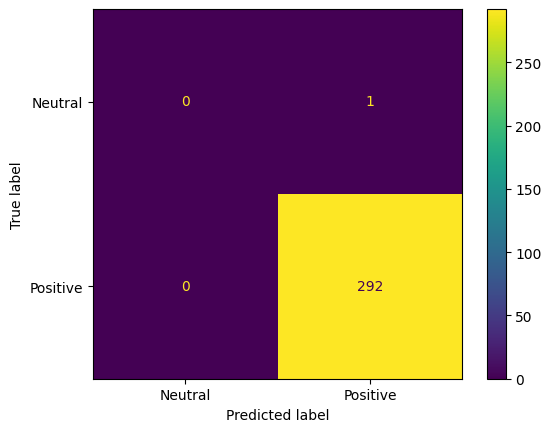

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, preds, target_names=le.classes_))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()